In [25]:
# import

import datetime
import pandas as pd # for dataframes aka the n.n data
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web # in industry we use GCP (google cloud Plt)
from scipy.stats.mstats import winsorize

In [11]:
stock_ticker = "GFTC" # Strings : represent labels or names
market_price = 150.25 # FLOAT
share_traded = 1000 # integer
is_volatile = True # BOOLEAN

print(f"Asset: {stock_ticker}")
print(f"Market Price: {market_price}")
print(f"Shares Traded: {share_traded}")
print(f"Is Volatile: {is_volatile}")
print(f" Asset  {stock_ticker} | Price : {share_traded} | Type: {is_volatile}")

Asset: GFTC
Market Price: 150.25
Shares Traded: 1000
Is Volatile: True
 Asset  GFTC | Price : 1000 | Type: True


In [18]:
data = { 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'], 'Sector': ['Tech', 'Fin', 'Tech', 'Energy', 'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'], 'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0], 'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10], 'Description': ['High growth tech', 'Stable financial', 'Volatile software', 'Oil production', 'Unknown bank', 'AI startup', 'Solar energy', 'E-commerce', 'Store A', 'Store B'] }

In [19]:
df_fin = pd.DataFrame(data)
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description
0,A1,Tech,0.05,0.12,High growth tech
1,A2,Fin,0.02,0.08,Stable financial
2,A3,Tech,-0.01,0.15,Volatile software
3,A4,Energy,0.08,0.20,Oil production
4,A5,Fin,NaN,0.10,Unknown bank


In [21]:
df_fin['Returns_Imp']= df_fin['Returns'].fillna(df_fin['Returns'].mean())
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp
0,A1,Tech,0.05,0.12,High growth tech,0.050000
1,A2,Fin,0.02,0.08,Stable financial,0.020000
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000
3,A4,Energy,0.08,0.20,Oil production,0.080000
4,A5,Fin,NaN,0.10,Unknown bank,0.591111


In [22]:
print(f"Gaps filled with the means is not perfect but good. Total NaNs now : {df_fin['Returns_Imp'].isna().sum()} ")

Gaps filled with the means is not perfect but good. Total NaNs now : 0 


In [29]:
# outliers and winsorisation
# in finance we observe fat tails. A single error can ruin a model
# winsorisation caps extreme values rather than deleting them

df_fin['Returns_Clean']=winsorize(df_fin['Returns'], limits=[0.05,0.95])
display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Clean
0,A1,Tech,0.05,0.12,High growth tech,0.050000,-0.02
1,A2,Fin,0.02,0.08,Stable financial,0.020000,-0.02
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.02
3,A4,Energy,0.08,0.20,Oil production,0.080000,-0.02
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,-0.02


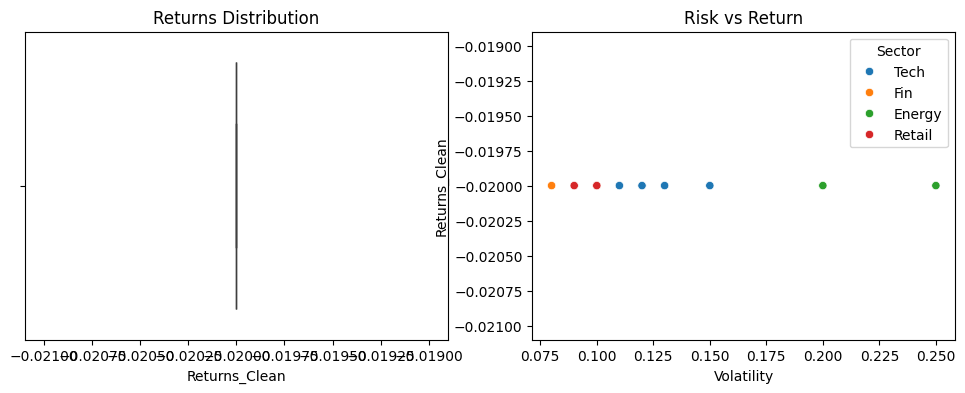

In [31]:
# Data visualisation

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

import seaborn as sns

sns.boxplot(x=df_fin['Returns_Clean']).set_title("Returns Distribution")

plt.subplot(1,2,2)
sns.scatterplot(data=df_fin, x='Volatility', y='Returns_Clean', hue='Sector').set_title("Risk vs Return")
plt.show()

In [32]:
import statsmodels.api as sm

In [33]:
X = sm.add_constant(df_fin['Volatility'])
y = df_fin['Returns_Clean']

model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                     -12.900
Model:                            OLS   Adj. R-squared:                -14.638
Method:                 Least Squares   F-statistic:                    -7.424
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               1.00
Time:                        13:10:54   Log-Likelihood:                 374.68
No. Observations:                  10   AIC:                            -745.4
Df Residuals:                       8   BIC:                            -744.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0200   1.28e-17  -1.57e+15      0.0

In [34]:
from sklearn.cluster import KMeans

In [35]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(df_fin[['Returns_Clean', 'Volatility']])
df_fin['Risk_Group'] = kmeans.labels_
print("Assets assigned to risk clusters.")


Assets assigned to risk clusters.


In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

df_fin['Target'] = (df_fin['Sector'] == 'Tech').astype(int)
X_clf = df_fin[['Returns_Clean', 'Volatility']]
y_clf = df_fin['Target']

clf = DecisionTreeClassifier().fit(X_clf, y_clf)
df_fin['Prediction'] = clf.predict(X_clf)
print(classification_report(y_clf, df_fin['Prediction']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
# Financial data analysis with the internet


In [39]:
import datetime
import yfinance as yf # Import yfinance

# Define the ticker for S&P 500
sp500_ticker = '^GSPC'

# Define the date range from 2020 to 2023
start_date = datetime.datetime(2020, 1, 1)
end_date = datetime.datetime(2023, 12, 31)

# Fetch S&P 500 data using yfinance
sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)

# Display the first few rows of the data
display(sp500_data.head())

/tmp/ipykernel_12009/2932825157.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


In [40]:
#since it is more than just simple DA
# we need to install the SQL package
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=1819ad9f4608c6d67a0ca85c7729dd326719588693712544f567ae1f1b08c1aa
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [41]:
import sqlite3

In [42]:
conn =sqlite3.connect(':memory:')
# creates an in-memory SQLite DB (database) so you use the vm of google

In [43]:
df_fin.to_sql('finance_table', conn, index=False, if_exists='replace')
#then write the existing df_fin to the SQL database

10

In [44]:
query = "SELECT Sector, AVG(Volatility) as Avg_Vol FROM finance_table GROUP BY Sector"
sql_results = pd.read_sql_query(query, conn)
display(sql_results)


,Sector,Avg_Vol
0,Energy,0.2250
1,Fin,0.0900
2,Retail,0.0950
3,Tech,0.1275


In [45]:
# using only SQL and not pandas
# can use a lambda function

from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())



In [49]:
query_ps = """
SELECT Asset_ID, Sector, Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""

In [50]:
print(pysqldf(query_ps))

  Asset_ID Sector  Returns_Clean
0       A1   Tech          -0.02
1       A3   Tech          -0.02
2       A6   Tech          -0.02
3       A8   Tech          -0.02


In [51]:
asset_metadata = pd.DataFrame({ 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'], 'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft', 'Exxon Mobil', 'Goldman Sachs'], 'Country': ['USA', 'USA', 'USA', 'USA', 'USA'] })

In [52]:
# the advantage of SQL is the power of JOINING TABLES
# The most used one is INNER JOIN

# WE WILL DO AN API call for the FRED
fred_df_sql = sql = fred_data.reset_index()

NameError: name 'fred_data' is not defined